In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv('data/WA_Fn-UseC_-Telco-Customer-Churn.xls')

In [4]:
df.shape

(7043, 21)

In [5]:
df.isna().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [8]:
df.nunique()

customerID          7043
gender                 2
SeniorCitizen          2
Partner                2
Dependents             2
tenure                73
PhoneService           2
MultipleLines          3
InternetService        3
OnlineSecurity         3
OnlineBackup           3
DeviceProtection       3
TechSupport            3
StreamingTV            3
StreamingMovies        3
Contract               3
PaperlessBilling       2
PaymentMethod          4
MonthlyCharges      1585
TotalCharges        6531
Churn                  2
dtype: int64

In [9]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [10]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [11]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

In [12]:
df.isna().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [13]:
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].mean())

In [14]:
df.isna().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [15]:
df.drop(columns=['customerID'],inplace=True)

In [16]:
numerical_feature = [feature for feature in df.columns if df[feature].dtype != 'str']
categorical_feature = [feature for feature in df.columns if df[feature].dtype == 'str']

In [17]:
numerical_feature

['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']

In [18]:
categorical_feature

['gender',
 'Partner',
 'Dependents',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod',
 'Churn']

In [19]:
for feature in categorical_feature:
    print(f'{feature} : ', df[feature].unique())

gender :  <StringArray>
['Female', 'Male']
Length: 2, dtype: str
Partner :  <StringArray>
['Yes', 'No']
Length: 2, dtype: str
Dependents :  <StringArray>
['No', 'Yes']
Length: 2, dtype: str
PhoneService :  <StringArray>
['No', 'Yes']
Length: 2, dtype: str
MultipleLines :  <StringArray>
['No phone service', 'No', 'Yes']
Length: 3, dtype: str
InternetService :  <StringArray>
['DSL', 'Fiber optic', 'No']
Length: 3, dtype: str
OnlineSecurity :  <StringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str
OnlineBackup :  <StringArray>
['Yes', 'No', 'No internet service']
Length: 3, dtype: str
DeviceProtection :  <StringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str
TechSupport :  <StringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str
StreamingTV :  <StringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str
StreamingMovies :  <StringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str
Contract :  <StringArray>
['Mont

In [20]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [21]:
# target_cols = [
#     col for col in df.select_dtypes(include=['object', 'string']).columns
#     if df[col].astype(str).str.contains(' ').any()
# ]
for col in categorical_feature:
    df[col] =  df[col].str.replace(' ', '')
    df[col] =  df[col].str.replace('-', '')

In [22]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,Nophoneservice,DSL,No,Yes,No,No,No,No,Monthtomonth,Yes,Electroniccheck,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,Oneyear,No,Mailedcheck,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Monthtomonth,Yes,Mailedcheck,53.85,108.15,Yes
3,Male,0,No,No,45,No,Nophoneservice,DSL,Yes,No,Yes,Yes,No,No,Oneyear,No,Banktransfer(automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiberoptic,No,No,No,No,No,No,Monthtomonth,Yes,Electroniccheck,70.70,151.65,Yes


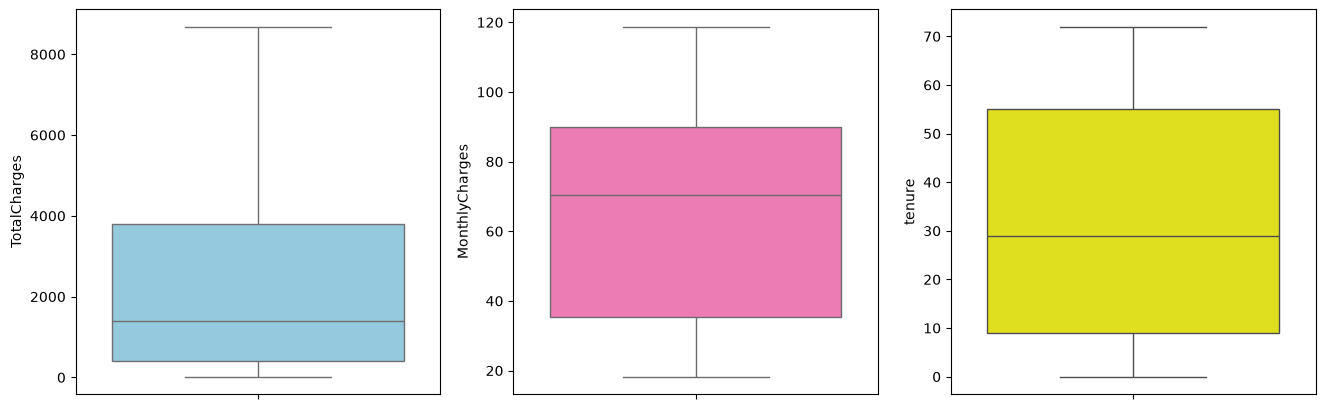

In [23]:
plt.subplots(1,3,figsize=(16,5))
plt.subplot(131)
sns.boxplot(df['TotalCharges'],color='skyblue')
plt.subplot(132)
sns.boxplot(df['MonthlyCharges'],color='hotpink')
plt.subplot(133)
sns.boxplot(df['tenure'],color='yellow')
plt.show()


In [24]:
df['Churn'].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [25]:
pd.crosstab([df['StreamingMovies'],df['StreamingTV']],df['Churn'],normalize='index')

Churn                                      No       Yes
StreamingMovies   StreamingTV                          
No                No                 0.655600  0.344400
                  Yes                0.683181  0.316819
Nointernetservice Nointernetservice  0.925950  0.074050
Yes               No                 0.688131  0.311869
                  Yes                0.705670  0.294330

Text(0.5, 1.0, 'Churn Count by Senior Citizen Status')

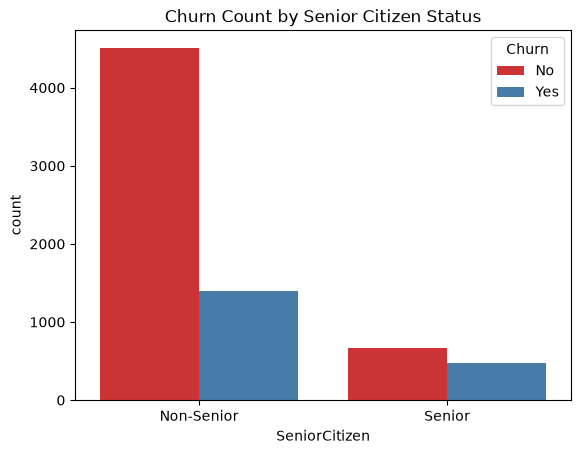

In [26]:
sns.countplot(data=df, x='SeniorCitizen', hue='Churn', palette='Set1')
plt.xticks([0,1], ['Non-Senior', 'Senior'])
plt.title('Churn Count by Senior Citizen Status')

Text(0.5, 1.0, 'Churn Count by Partner Status')

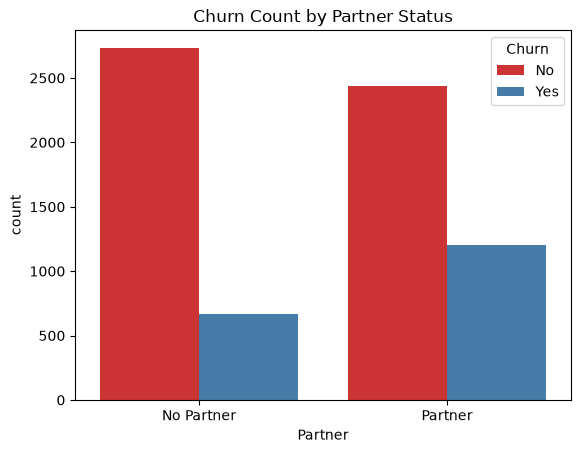

In [27]:
sns.countplot(data=df, x='Partner', hue='Churn', palette='Set1')
plt.xticks([0,1], ['No Partner', 'Partner'])
plt.title('Churn Count by Partner Status')

Text(0.5, 1.0, 'Churn Count by Dependents Status')

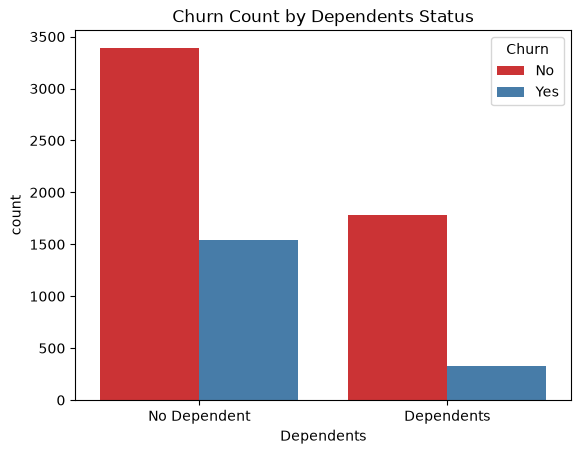

In [28]:
sns.countplot(data=df, x='Dependents', hue='Churn', palette='Set1')
plt.xticks([0,1], ['No Dependent', 'Dependents'])
plt.title('Churn Count by Dependents Status')

In [29]:
df['HasFamily'] = ((df['Partner'] == 'Yes') | (df['Dependents'] == 'Yes')).map({True: 'Yes', False: 'No'})

In [30]:
df['HasFamily'].value_counts()

HasFamily
Yes    3763
No     3280
Name: count, dtype: int64

<Axes: xlabel='Churn', ylabel='tenure'>

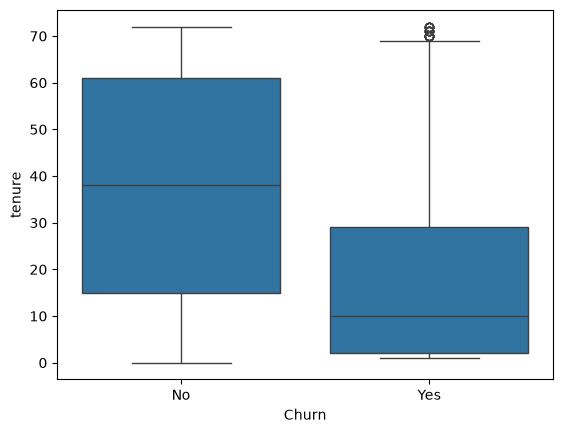

In [31]:
sns.boxplot(data=df, x='Churn', y='tenure')

In [39]:
df['tenure'].max()

np.int64(72)

<Axes: xlabel='Churn', ylabel='MonthlyCharges'>

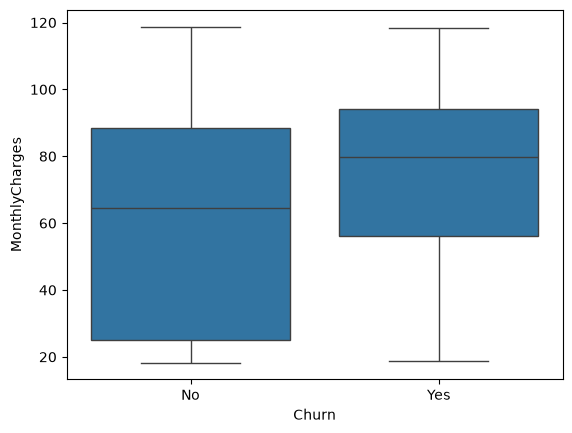

In [47]:
sns.boxplot(data=df, x='Churn', y='MonthlyCharges')

<Axes: xlabel='Churn', ylabel='TotalCharges'>

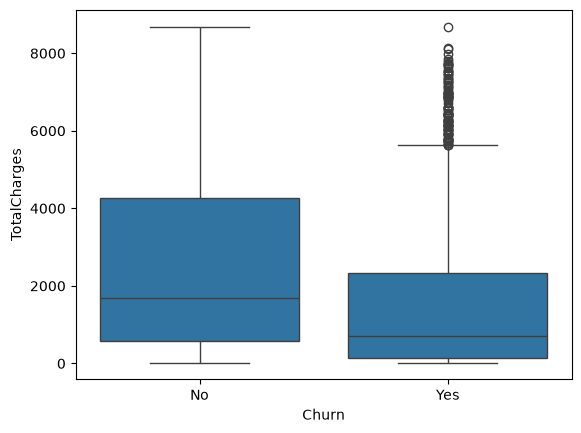

In [48]:
sns.boxplot(data=df, x='Churn', y='TotalCharges')

In [49]:
print(df['TotalCharges'].max())
print(df['TotalCharges'].min())

8684.8
18.8


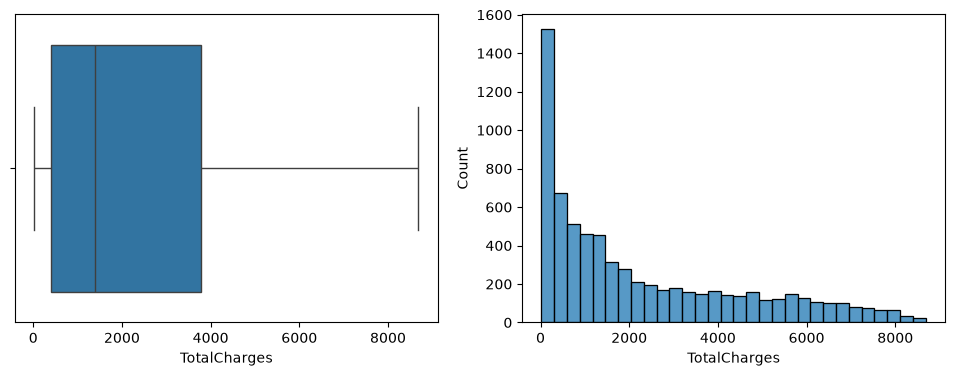

In [50]:
fig, axes = plt.subplots(1, 2, figsize=(12,4))
sns.boxplot(x=df['TotalCharges'], ax=axes[0])
sns.histplot(df['TotalCharges'], bins=30, ax=axes[1])
plt.show()

In [60]:
Q1, Q3 = df['TotalCharges'].quantile([0.25, 0.75])
IQR = Q3 - Q1
outliers = df[(df['TotalCharges'] < Q1 - 1.5*IQR) | (df['TotalCharges'] > Q3 + 1.5*IQR)]

lower_bound = Q1-1.5*IQR
upper_bound = Q3+1.5*IQR

print(df['TotalCharges'].max())
print(upper_bound)
print(df['TotalCharges'].min())
print(lower_bound)

df = df[(df['TotalCharges'] >= lower_bound) & (df['TotalCharges'] <= upper_bound)]


8684.8
8863.1625
18.8
-4674.3375


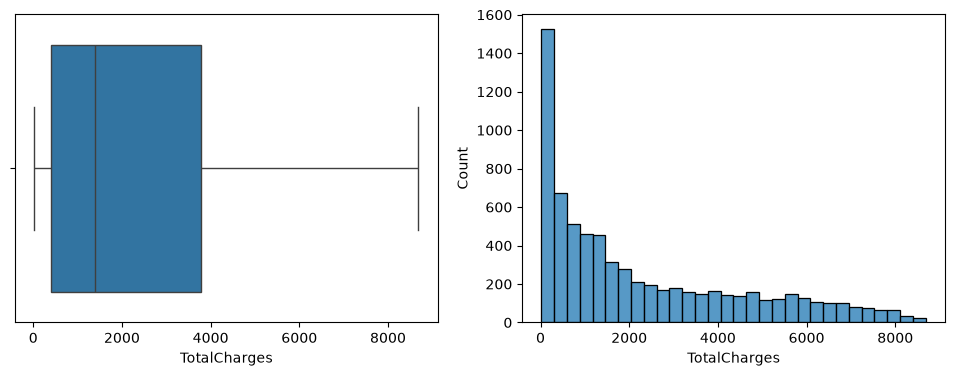

In [56]:
fig, axes = plt.subplots(1, 2, figsize=(12,4))
sns.boxplot(x=df['TotalCharges'], ax=axes[0])
sns.histplot(df['TotalCharges'], bins=30, ax=axes[1])
plt.show()

<Axes: xlabel='Churn', ylabel='TotalCharges'>

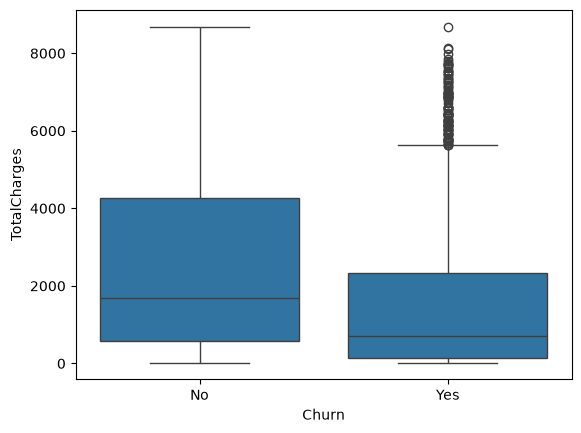

In [57]:
sns.boxplot(data=df, x='Churn', y='TotalCharges')